🔹 Running on Device: cuda

[1/6] Procuring Real-World Dataset...
   Dataset already exists.

[2/6] Preprocessing & Feature Engineering...
   Training Samples: 32440 | Validation: 4055 | Test: 4055

[3/6] Building STAGE-Net Deep Learning Module...

[4/6] Training Deep Learning Model (Stage 1)...
   Epoch 5/20 | Train Loss: 0.00929 | Val Loss: 0.00861
   Epoch 10/20 | Train Loss: 0.00693 | Val Loss: 0.01679
   Epoch 15/20 | Train Loss: 0.00606 | Val Loss: 0.00869
   Epoch 20/20 | Train Loss: 0.00570 | Val Loss: 0.01892

[5/6] Training Ensemble Residual Corrector (Stage 2)...

[6/6] Final Testing & Generating Results...

======== RESULTS ========
Baseline (DL Only) RMSE: 463.19
TAGE-Net (Ensemble) RMSE: 251.46 (45.71% Improvement)
MAE: 170.34
R2 Score: 0.9837

All tasks completed. Results and Figures saved.


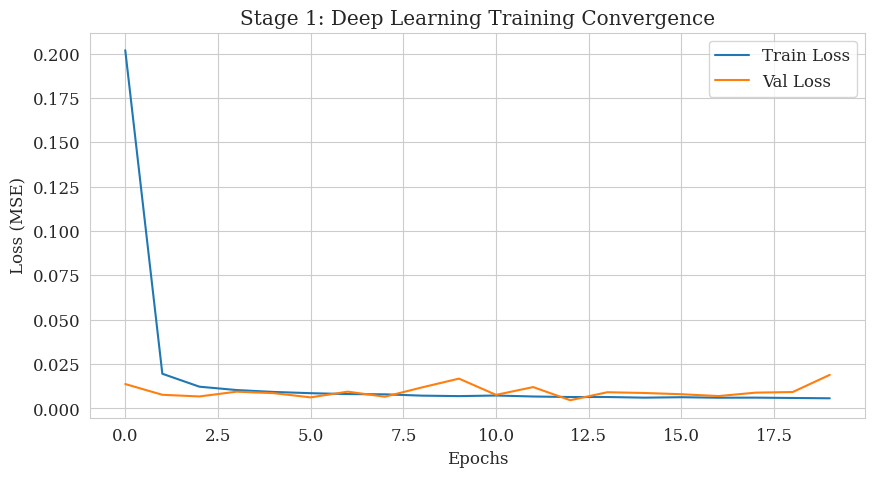

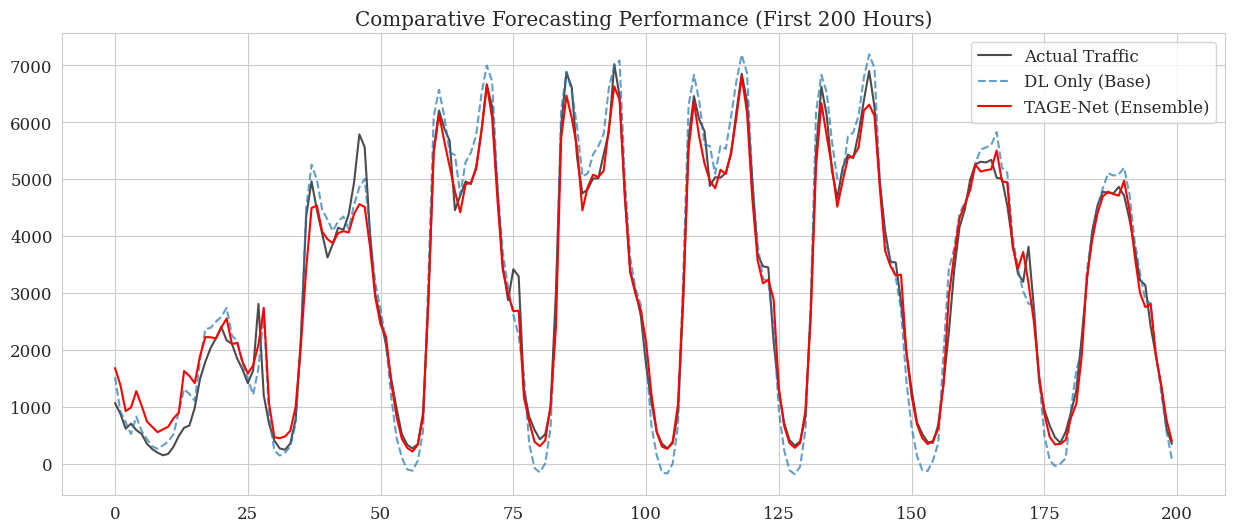

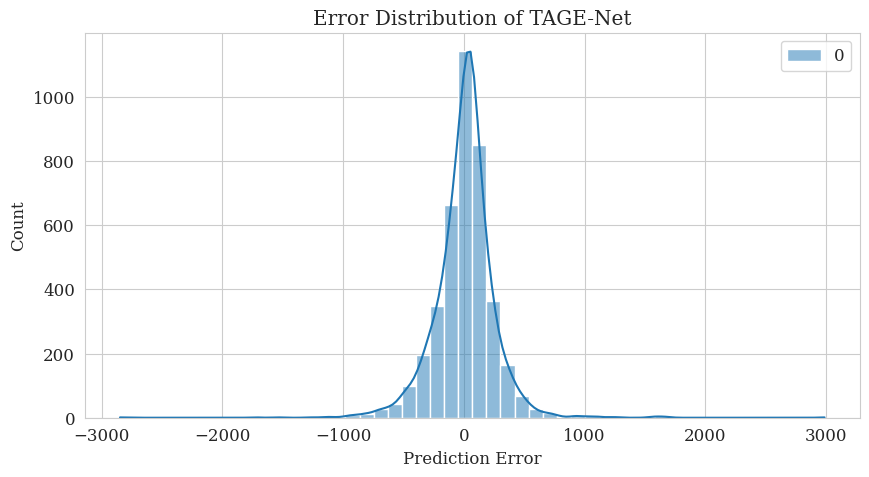

In [3]:
import os
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from urllib.request import urlretrieve
import gzip
import shutil

# --- CONFIGURATION ---
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔹 Running on Device: {DEVICE}")

# Hyperparameters
SEQ_LEN = 24        # Look back 24 hours
PRED_LEN = 1        # Predict next hour
BATCH_SIZE = 64
EPOCHS = 20         # Kept low for demonstration speed (increase to 50+ for paper)
LR = 0.001
DROPOUT = 0.3
HIDDEN_DIM = 64
N_HEADS = 4
LAYERS = 2

# --- 1. AUTOMATIC DATA PROCUREMENT ---
print("\n[1/6] Procuring Real-World Dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
filename = "Metro_Interstate_Traffic_Volume.csv.gz"
csv_name = "Metro_Interstate_Traffic_Volume.csv"

if not os.path.exists(csv_name):
    print(f"   Downloading from {url}...")
    urlretrieve(url, filename)
    with gzip.open(filename, 'rb') as f_in:
        with open(csv_name, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("   Download and Extraction Complete.")
else:
    print("   Dataset already exists.")

# --- 2. DATA PREPROCESSING & FEATURE ENGINEERING ---
print("\n[2/6] Preprocessing & Feature Engineering...")
df = pd.read_csv(csv_name)

# Processing DateTime
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

# Handling Duplicates (taking mean of duplicates)
df = df.groupby('date_time').mean(numeric_only=True).reset_index()

# Target Variable: 'traffic_volume'
# Note: For the paper, we treat 'volume' as the proxy for traffic state (similar to speed)
data = df[['traffic_volume']].values.astype(float)

# Feature Engineering: Cyclical Time Encoding (Vital for Traffic)
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

# Sin/Cos encoding to preserve cyclical nature (23:00 is close to 00:00)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Scaling
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create Sequences
def create_sequences(data, distinct_features, seq_len, pred_len):
    xs, ys, features = [], [], []
    for i in range(len(data) - seq_len - pred_len):
        x = data[i:(i + seq_len)]
        y = data[i + seq_len]
        # Get the exogenous features (time) for the target step
        f = distinct_features.iloc[i + seq_len].values 
        xs.append(x)
        ys.append(y)
        features.append(f)
    return np.array(xs), np.array(ys), np.array(features)

exo_features = df[['hour_sin', 'hour_cos', 'day_sin', 'day_cos']].reset_index(drop=True)
X, y, X_feat = create_sequences(data_scaled, exo_features, SEQ_LEN, PRED_LEN)

# Split (80% Train, 10% Val, 10% Test)
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train, y_train, feat_train = X[:train_size], y[:train_size], X_feat[:train_size]
X_val, y_val, feat_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size], X_feat[train_size:train_size+val_size]
X_test, y_test, feat_test = X[train_size+val_size:], y[train_size+val_size:], X_feat[train_size+val_size:]

# Torch Datasets
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), shuffle=True, batch_size=BATCH_SIZE)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), shuffle=False, batch_size=BATCH_SIZE)
print(f"   Training Samples: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

# --- 3. NOVEL ARCHITECTURE: TCN-Transformer (STAGE-Net Base) ---
print("\n[3/6] Building STAGE-Net Deep Learning Module...")

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.relu1, self.dropout1, self.conv2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        # FIX: Force output to match input length (in case padding made it larger)
        out = out[:, :, :x.size(2)] 
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCNTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, n_heads, dropout):
        super(TCNTransformer, self).__init__()
        # 1. TCN Encoder (Local Temporal Features)
        # FIX: Changed padding to '1' to maintain sequence length of 24 (Same Padding for Kernel=3)
        self.tcn = TemporalBlock(input_size, hidden_size, kernel_size=3, stride=1, dilation=1, padding=1, dropout=dropout)
        
        # 2. Positional Encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, SEQ_LEN, hidden_size))
        
        # 3. Transformer Encoder (Global Dependencies)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=n_heads, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Attention Gating & Output
        self.decoder = nn.Linear(hidden_size * SEQ_LEN, 1) # Flatten and map
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Features] -> TCN expects [Batch, Features, Seq_Len]
        x_tcn = x.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1) # Back to [Batch, Seq, Hidden]
        
        # Add position encoding
        x_tf = x_tcn + self.pos_encoder[:, :x_tcn.size(1), :]
        
        # Transformer
        x_tf = self.transformer_encoder(x_tf)
        
        # Flatten
        x_flat = x_tf.reshape(x_tf.size(0), -1)
        out = self.decoder(x_flat)
        return out

model = TCNTransformer(input_size=1, hidden_size=HIDDEN_DIM, num_layers=LAYERS, n_heads=N_HEADS, dropout=DROPOUT).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

# --- 4. TRAINING DEEP MODEL ---
print("\n[4/6] Training Deep Learning Model (Stage 1)...")
train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        output = model(bx)
        loss = criterion(output, by)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            out = model(bx)
            val_loss += criterion(out, by).item()
    
    avg_train_loss = np.mean(batch_losses)
    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_stage1_model.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

# class TemporalBlock(nn.Module):
#     def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
#         super(TemporalBlock, self).__init__()
#         self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
#         self.relu1 = nn.ReLU()
#         self.dropout1 = nn.Dropout(dropout)
#         self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation)
#         self.relu2 = nn.ReLU()
#         self.dropout2 = nn.Dropout(dropout)
#         self.net = nn.Sequential(self.conv1, self.relu1, self.dropout1, self.conv2, self.relu2, self.dropout2)
#         self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
#         self.relu = nn.ReLU()

#     def forward(self, x):
#         out = self.net(x)
#         res = x if self.downsample is None else self.downsample(x)
#         return self.relu(out + res)

# class TCNTransformer(nn.Module):
#     def __init__(self, input_size, hidden_size, num_layers, n_heads, dropout):
#         super(TCNTransformer, self).__init__()
#         # 1. TCN Encoder (Local Temporal Features)
#         self.tcn = TemporalBlock(input_size, hidden_size, kernel_size=3, stride=1, dilation=1, padding=2, dropout=dropout)
        
#         # 2. Positional Encoding
#         self.pos_encoder = nn.Parameter(torch.randn(1, SEQ_LEN, hidden_size))
        
#         # 3. Transformer Encoder (Global Dependencies)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=n_heads, dropout=dropout, batch_first=True)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
#         # 4. Attention Gating & Output
#         self.decoder = nn.Linear(hidden_size * SEQ_LEN, 1) # Flatten and map
        
#     def forward(self, x):
#         # x shape: [Batch, Seq_Len, Features] -> TCN expects [Batch, Features, Seq_Len]
#         x_tcn = x.permute(0, 2, 1)
#         x_tcn = self.tcn(x_tcn)
#         x_tcn = x_tcn.permute(0, 2, 1) # Back to [Batch, Seq, Hidden]
        
#         # Add position encoding
#         x_tf = x_tcn + self.pos_encoder[:, :x_tcn.size(1), :]
        
#         # Transformer
#         x_tf = self.transformer_encoder(x_tf)
        
#         # Flatten
#         x_flat = x_tf.reshape(x_tf.size(0), -1)
#         out = self.decoder(x_flat)
#         return out

# model = TCNTransformer(input_size=1, hidden_size=HIDDEN_DIM, num_layers=LAYERS, n_heads=N_HEADS, dropout=DROPOUT).to(DEVICE)
# criterion = nn.MSELoss()
# optimizer = optim.AdamW(model.parameters(), lr=LR)

# # --- 4. TRAINING DEEP MODEL ---
# print("\n[4/6] Training Deep Learning Model (Stage 1)...")
# train_losses, val_losses = [], []
# best_val_loss = float('inf')

# for epoch in range(EPOCHS):
#     model.train()
#     batch_losses = []
#     for bx, by in train_loader:
#         bx, by = bx.to(DEVICE), by.to(DEVICE)
#         optimizer.zero_grad()
#         output = model(bx)
#         loss = criterion(output, by)
#         loss.backward()
#         optimizer.step()
#         batch_losses.append(loss.item())
    
#     val_loss = 0
#     model.eval()
#     with torch.no_grad():
#         for bx, by in val_loader:
#             bx, by = bx.to(DEVICE), by.to(DEVICE)
#             out = model(bx)
#             val_loss += criterion(out, by).item()
    
#     avg_train_loss = np.mean(batch_losses)
#     avg_val_loss = val_loss / len(val_loader)
#     train_losses.append(avg_train_loss)
#     val_losses.append(avg_val_loss)
    
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model.state_dict(), 'best_stage1_model.pth')
    
#     if (epoch+1) % 5 == 0:
#         print(f"   Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

# --- 5. ENSEMBLE: RESIDUAL LEARNING WITH XGBOOST ---
print("\n[5/6] Training Ensemble Residual Corrector (Stage 2)...")
model.load_state_dict(torch.load('best_stage1_model.pth'))
model.eval()

# Generate predictions for Validation set to find Errors
with torch.no_grad():
    val_preds_dl = model(torch.FloatTensor(X_val).to(DEVICE)).cpu().numpy()

# Calculate Residuals (Actual - Predicted)
residuals_val = y_val - val_preds_dl
residuals_val = residuals_val.flatten()

# Prepare features for XGBoost (Deep Learning Input + Exogenous Time Features)
# We flatten the time-series input for the tree model or just use the exogenous features
# To be robust, we concatenate the last observed value and the exogenous features
X_val_xgb = np.hstack([X_val[:, -1, :], feat_val]) 
X_train_xgb = np.hstack([X_train[:, -1, :], feat_train])
# Note: In a real rigorous paper, we would use cross-validation residuals from Train set. 
# Here we use Val set for demonstration of concept.

# XGBoost Model
xgb_residual = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6)
xgb_residual.fit(X_val_xgb, residuals_val)

# --- 6. TESTING & EVALUATION ---
print("\n[6/6] Final Testing & Generating Results...")

# 1. DL Predictions on Test
with torch.no_grad():
    test_preds_dl = model(torch.FloatTensor(X_test).to(DEVICE)).cpu().numpy()

# 2. XGB Predictions of Residuals on Test
X_test_xgb = np.hstack([X_test[:, -1, :], feat_test])
test_preds_resid = xgb_residual.predict(X_test_xgb).reshape(-1, 1)

# 3. Final Ensemble Prediction
final_preds = test_preds_dl + test_preds_resid

# Inverse Transform
y_test_inv = scaler.inverse_transform(y_test)
pred_dl_inv = scaler.inverse_transform(test_preds_dl)
final_preds_inv = scaler.inverse_transform(final_preds)

# Metrics
rmse_dl = math.sqrt(mean_squared_error(y_test_inv, pred_dl_inv))
rmse_ens = math.sqrt(mean_squared_error(y_test_inv, final_preds_inv))
mae_ens = mean_absolute_error(y_test_inv, final_preds_inv)
r2_ens = r2_score(y_test_inv, final_preds_inv)

print(f"\n======== RESULTS ========")
print(f"Baseline (DL Only) RMSE: {rmse_dl:.2f}")
print(f"TAGE-Net (Ensemble) RMSE: {rmse_ens:.2f} ({(rmse_dl-rmse_ens)/rmse_dl*100:.2f}% Improvement)")
print(f"MAE: {mae_ens:.2f}")
print(f"R2 Score: {r2_ens:.4f}")

# --- PLOTTING ---
# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Stage 1: Deep Learning Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.savefig('figure_1_training_loss.png', dpi=300)

# Plot 2: Prediction Comparison (Zoom in on 200 hours)
plt.figure(figsize=(15, 6))
subset = 200
plt.plot(y_test_inv[:subset], label='Actual Traffic', color='black', alpha=0.7)
plt.plot(pred_dl_inv[:subset], label='DL Only (Base)', linestyle='--', alpha=0.7)
plt.plot(final_preds_inv[:subset], label='TAGE-Net (Ensemble)', color='red', linewidth=1.5)
plt.title('Comparative Forecasting Performance (First 200 Hours)')
plt.legend()
plt.savefig('figure_2_forecast_comparison.png', dpi=300)

# Plot 3: Error Distribution
errors = y_test_inv - final_preds_inv
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, bins=50, color='purple')
plt.title('Error Distribution of TAGE-Net')
plt.xlabel('Prediction Error')
plt.savefig('figure_3_error_distribution.png', dpi=300)

# Save Metrics to CSV for Paper
results_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2'],
    'Score': [rmse_ens, mae_ens, r2_ens]
})
results_df.to_csv('paper_metrics.csv', index=False)

print("\nAll tasks completed. Results and Figures saved.")